In [21]:
%%capture
!pip install librosa praat-parselmouth opensmile

In [22]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio
import soundfile as sf

# Código: Cálculo de atributos del habla

In [23]:
x,sr = librosa.load("../../assets/murcielago.wav", sr=None)
Audio(x, rate=sr)

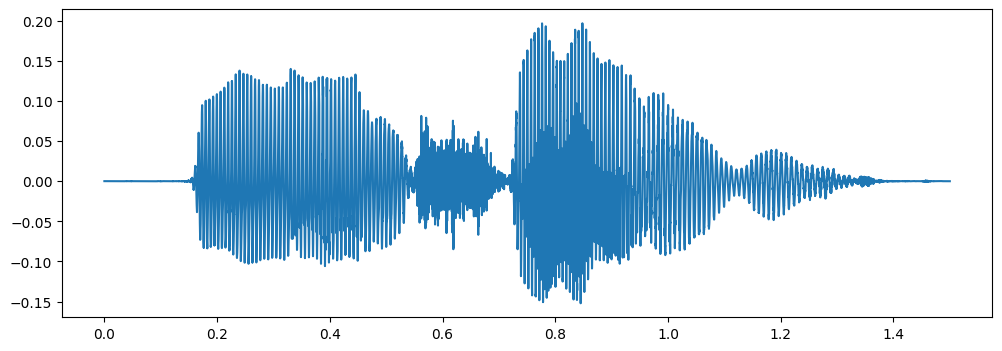

In [24]:
tx = np.arange(len(x)) / sr
plt.figure(figsize=(12, 4))
plt.plot(tx, x);
plt.show()

## Intensidad

Para calcular la energía "instantánea" de una señal, podemos tomar una ventana y calcular la energía en esa ventana. Esto se puede hacer utilizando la fórmula:

$$
E[t] = \frac{1}{N} \sum_{k=0}^N x^2[t+k]
$$

(640, 147)


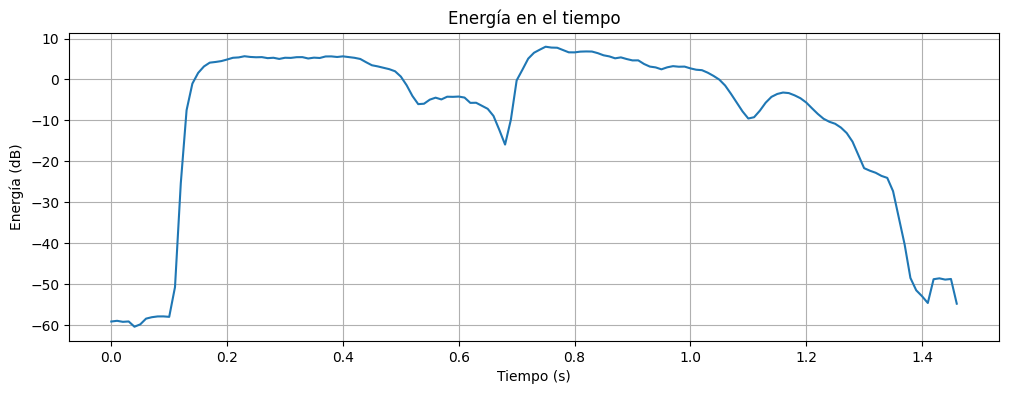

In [25]:
from librosa.util import frame # parte un audio en ventanas solapadas
from librosa import frames_to_time

win_length = int(0.04*sr) # 25ms
hop_length = int(0.01*sr) # 10ms
X = frame(x, frame_length=win_length, hop_length=hop_length)
tf = frames_to_time(np.arange(X.shape[1]), sr=sr, hop_length=hop_length)
I = (X**2).sum(0)
I_db = 10*np.log10(I+1e-10)
print(X.shape)

plt.figure(figsize=(12, 4))
plt.plot(tf, I_db)
plt.title('Energía en el tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Energía (dB)')
plt.grid()
plt.show()

## Tono (pitch)

Para calcular el tono (pitch) podemos hacer lo mismo con un algoritmo que calcule el pitch, por ejemplo basado en la autocorrelación. Al proceso se lo suele llamar pitch 
tracking. Calculemos la autocorrelación para cada ventana en el tiempo. El paso siguiente es seleccionar el pico de la autocorrelación que caiga dentro de la región esperable de frecuencia para la voz objetivo. Nos salteamos ese paso y graficamos arriba el resultado de otro algoritmo que calcule el pitch utilizando la función _librosa.pyin_.

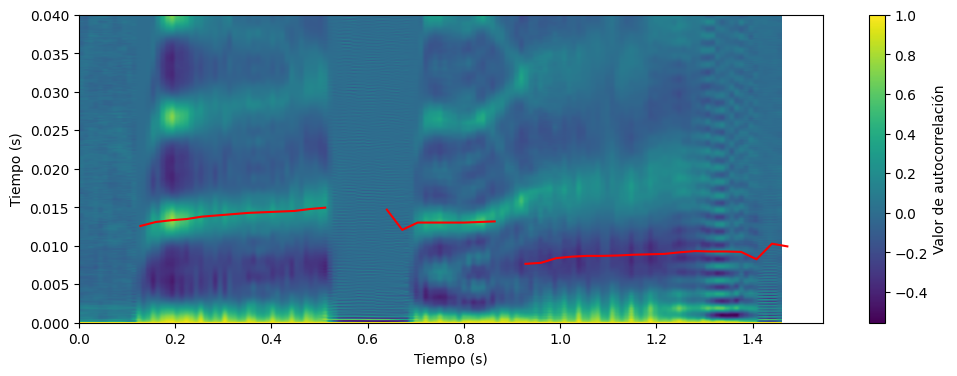

In [26]:
# autocorrelación para cada venta
acf = np.fft.irfft(np.abs(np.fft.rfft(X,axis=0)), axis=0).real
acf = acf / np.max(acf, axis=0) # normalizamos
acf = acf[:acf.shape[0]//2,:]
periodo = win_length / sr
plt.figure(figsize=(12, 4))
plt.imshow(acf, extent=(0, tf[-1], 0, periodo), aspect='auto', origin='lower');
plt.colorbar(label='Valor de autocorrelación')
f0, voiced_flag, voiced_probs = librosa.pyin(x,sr=sr,fmin=librosa.note_to_hz('C1'),fmax=librosa.note_to_hz('C3'))
times = librosa.times_like(f0, sr=sr)
plt.plot(times, 1/f0, label='periodo', color='r');
plt.xlabel('Tiempo (s)')
plt.ylabel('Tiempo (s)')
plt.show()

Vemos que el la estimación de pitch con _pyin_ calcula un período más chico (la mitad) del que realmente fue. Este fenómeno se lo llama _halving_ o _doubling_ dependiendo si se estima la mitad o el doble del tono.

### Praat

Praat es uno de los softwars de análisis de habla más clasicos y estables. Calculemos el pitch y la energía (
queda como tarea navegar el código fuente de Praat y tratar de entender que algoritmo usan)

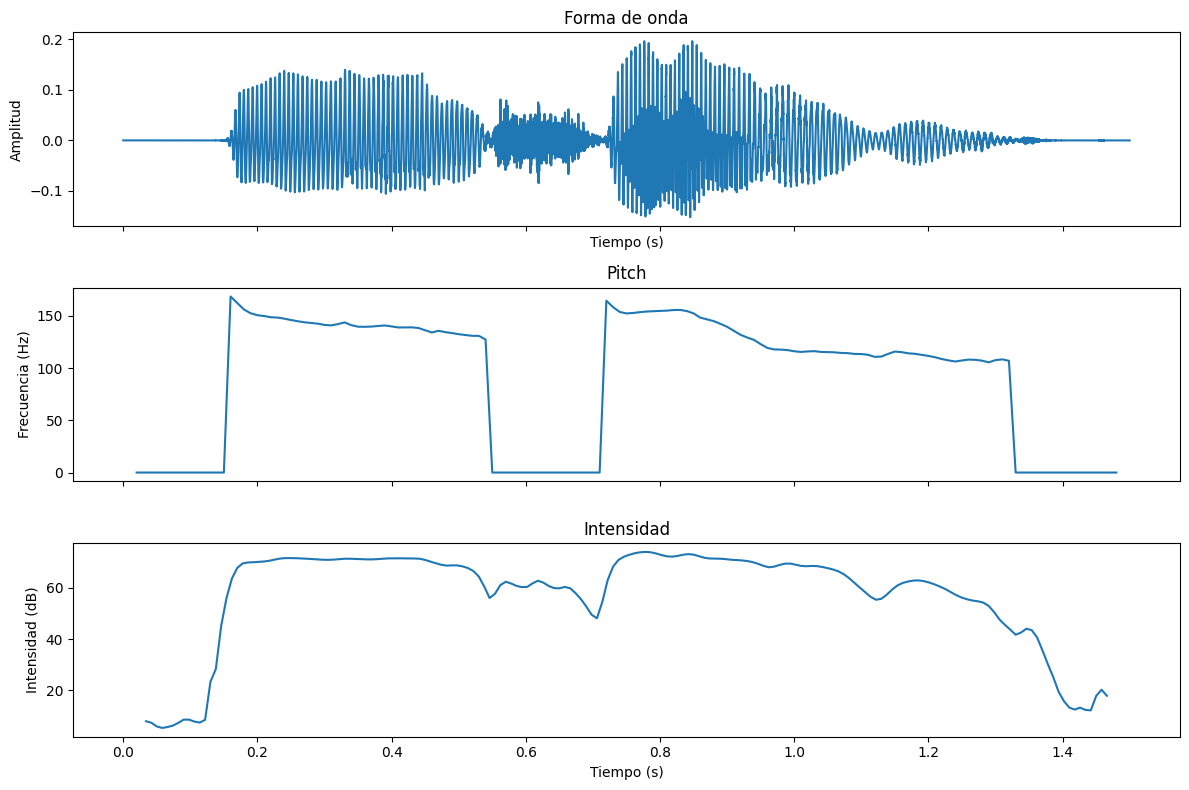

In [27]:
import parselmouth
from parselmouth.praat import call, run_file
import re
import pandas as pd


snd = parselmouth.Sound("../../assets/murcielago.wav")

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

x,sr = librosa.load("../../assets/murcielago.wav", sr=None)
display(Audio(x, rate=sr))

tx = np.arange(len(x)) / sr
axs[0].plot(tx, x)
axs[0].set_title('Forma de onda')
axs[0].set_ylabel('Amplitud')
axs[0].set_xlabel('Tiempo (s)')

pitch = snd.to_pitch()
xp = pitch.xs()
yp = pitch.selected_array['frequency']
axs[1].plot(xp,yp,label='Pitch')
axs[1].set_title('Pitch')
axs[1].set_ylabel('Frecuencia (Hz)')

intensity = snd.to_intensity()
xi = intensity.xs()
yi = intensity.as_array()[0]
axs[2].plot(xi,yi,label='Intensidad')
axs[2].set_title('Intensidad')
axs[2].set_xlabel('Tiempo (s)')
axs[2].set_ylabel('Intensidad (dB)')

plt.tight_layout()
plt.show()

## Formantes 

### Predicción linear (LPC, linear prediction coding)

Estimar frecuencias y anchos de banda de los formantes es un problema difícil. Una forma de hacerlo es mediante la predicción lineal, que se basa en el hecho de que la señal de audio puede ser modelada como una combinación lineal de sus muestras pasadas, similar a un filtro autoregresivo. 

Los coeficientes del filtro son la solución a la ecuación de predicción lineal:
$$
x[n] = \sum_{k=1}^{p} -a_k x[n-k] + e[n]
$$

donde $x[n]$ es la señal de audio, $a_k$ son los coeficientes LPC, $p$ es el orden del filtro y $e[n]$ es el error de predicción. Esta forma de modelarlo es identica a un modelo autoregresivo (AR). Si escribimos la ecuación de predicción lineal en términos de la señal predicha $\hat{x}[n]$, obtenemos: 

$$
\hat{x}[n] = \sum_{k=1}^{p} -a_k x[n-k]
$$

En este caso si consideramos a la señal predicha $\hat{x}[n]$ como una nueva señal, este es un filtro FIR o modelo de media movil (MA) donde la entrada es la señal original $x[n]$ y la salida es la señal predicha $\hat{x}[n]$.

Busquemos los coeficientes $a_k$ que minimizan el error cuadrático medio entre la señal original y la señal predicha para una vocal.

In [28]:
vocal = x[int(0.35*sr):int(0.43*sr)]
vocal = vocal - vocal.mean()
tv = np.arange(len(vocal)) / sr
Audio(vocal, rate=sr)

Podemos calcular los coeficientes LPC del orden que querramos usando librosa.

In [29]:
a = librosa.lpc(vocal, order=8)
print(a)

[ 1.         -2.2015815   1.0180401   0.03961618  0.8870125  -0.6470966
 -0.17548181 -0.12389356  0.20548624]


Podemos comparar la señal original con la señal predicha y ver cómo se comporta el error de predicción. Para esto armamos un filtro de FIR o media movial a partir de estos coeficientes, donde la entrada es la señal original y la salida es la señal predicha. 

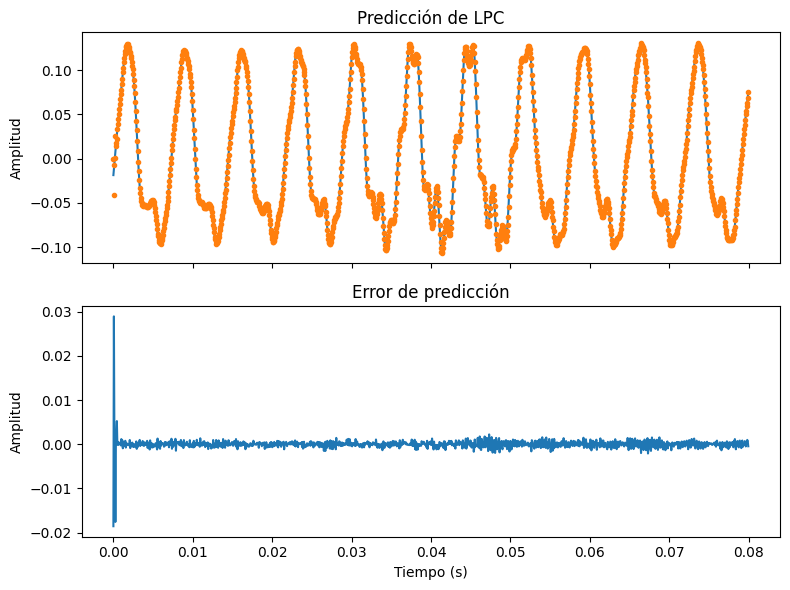

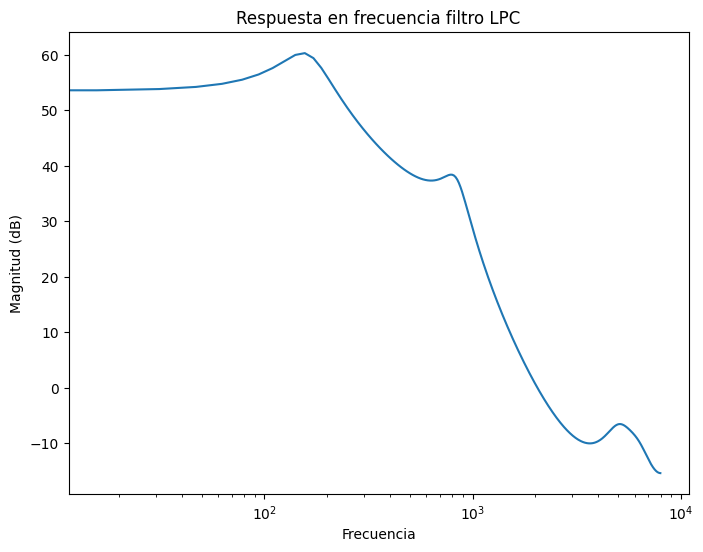

Polos:
  5: Frecuencia= 157.24 hz, BW= 79.14 hz
  6: Frecuencia= 830.13 hz, BW= 217.74 hz
  7: Frecuencia= 4990.49 hz, BW= 1611.07 hz
  8: Frecuencia= 6271.77 hz, BW= 2121.54 hz


/home/miles/miniconda3/envs/newbase/lib/python3.10/site-packages/scipy/signal/_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


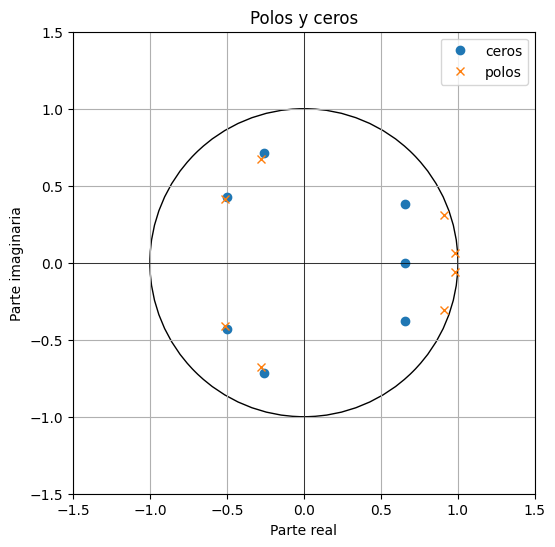

In [30]:
from scipy.signal import freqz, lfilter

a = librosa.lpc(vocal, order=8)
b = np.hstack([[0], -1 * a[1:]])

x_hat = lfilter(b, 1, vocal)

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(tv, vocal,  label='original')
axs[0].plot(tv, x_hat, '.', label='predicción')
axs[0].set_title('Predicción de LPC')
axs[0].set_ylabel('Amplitud')
axs[1].plot(tv, vocal - x_hat, label='error')
axs[1].set_title('Error de predicción')
axs[1].set_xlabel('Tiempo (s)')
axs[1].set_ylabel('Amplitud')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
w, h = freqz([1], a, worN=512, fs = sr)
plt.semilogx(w, 20 * np.log10(abs(h)),)
plt.title('Respuesta en frecuencia filtro LPC')
plt.xlabel('Frecuencia')
plt.ylabel('Magnitud (dB)')
plt.show()

# zeros an poles
from scipy.signal import zpk2tf, tf2zpk
z, p, k = tf2zpk(b, a)

p_r = np.abs(p)
p_bw = -2*sr*np.log(p_r)/2/np.pi
p_theta = np.angle(p)/np.pi*sr/2

# sort by theta
p_theta, p_bw = zip(*sorted(zip(p_theta, p_bw)))

print('Polos:')
for i in range(len(p)):
    if p_theta[i] > 0:
        print(f'  {i+1}: Frecuencia= {p_theta[i]:.2f} hz, BW= {p_bw[i]:.2f} hz')

# plot zeros and poles in unity circle

from matplotlib.patches import Circle
plt.figure(figsize=(6, 6))

plt.plot(np.real(z), np.imag(z), 'o', label='ceros')
plt.plot(np.real(p), np.imag(p), 'x', label='polos')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.title('Polos y ceros')
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
patch = plt.Circle((0, 0), 1, color='black', fill=False)
plt.gca().add_patch(patch)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid()
plt.show()

## Calidad del habla


### Atributos de calidad del habla

* Jitter: Variación de la frecuencia fundamental (F0) en el tiempo.
* Shimmer: Variación de la amplitud en el tiempo.
* HNR: Relación entre la energía de la voz y el ruido.

Calculamos estos atributos de calidad del habla utilizando Praat

Atributos calculados:
['Median pitch', 'Mean pitch', 'Standard deviation', 'Minimum pitch', 'Maximum pitch', 'Number of pulses', 'Number of periods', 'Mean period', 'Standard deviation of period', 'Fraction of locally unvoiced frames', 'Number of voice breaks', 'Degree of voice breaks', 'Jitter (local)', 'Jitter (local, absolute)', 'Jitter (rap)', 'Jitter (ppq5)', 'Jitter (ddp)', 'Shimmer (local)', 'Shimmer (local, dB)', 'Shimmer (apq3)', 'Shimmer (apq5)', 'Shimmer (apq11)', 'Shimmer (dda)', 'Mean autocorrelation', 'Mean noise-to-harmonics ratio', 'Mean harmonics-to-noise ratio']


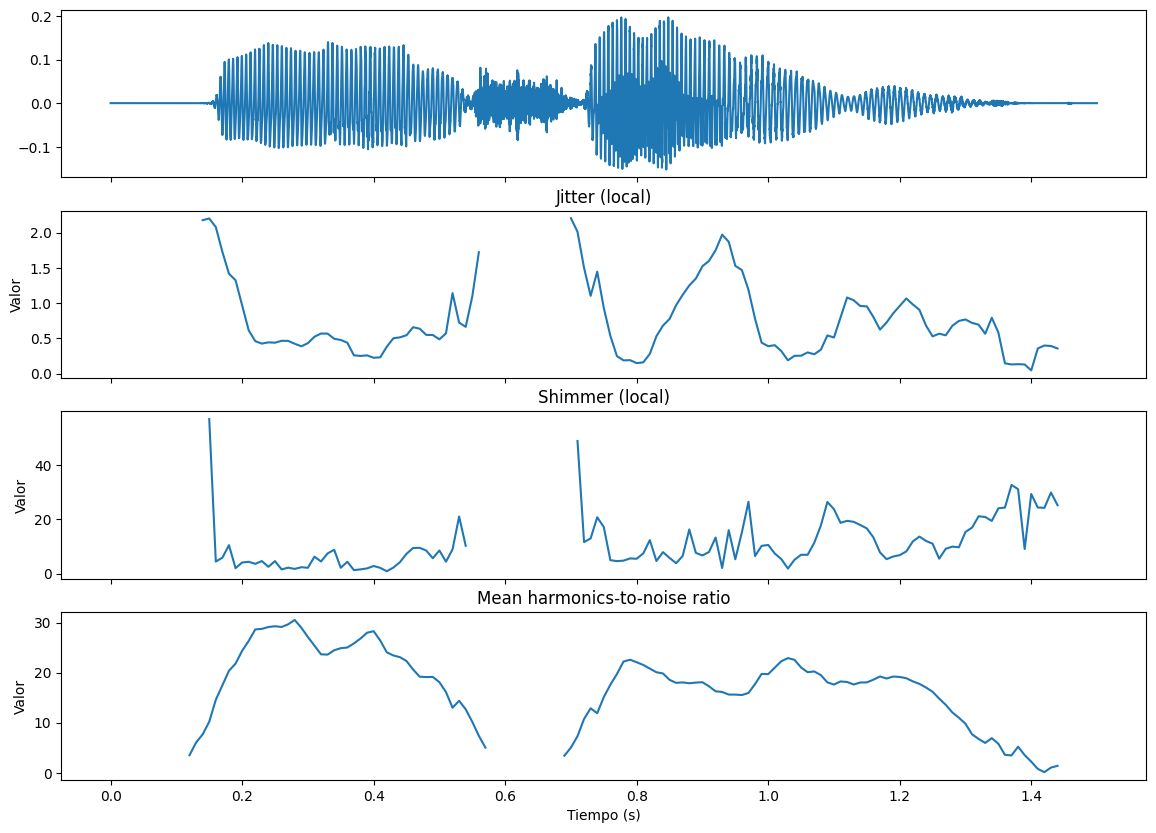

In [31]:
data = []
frame_length = 0.1
hop_length = 0.01
t1s = np.arange(0,snd.duration-frame_length,hop_length)
times = zip(t1s,t1s+frame_length) 
index = []
for t1,t2 in times:
  snd_ = snd.extract_part(t1,t2)
  pitch = snd_.to_pitch()
  pp = call(pitch, "To PointProcess")
  vr = call([snd_,pitch,pp], "Voice report",0, 0, 75, 500, 1.3, 1.6, 0.03, 0.45)
  data.append(dict(re.findall("(.*): (.*)",vr.replace('   ',''))[1:]))
#   index.append((t1,t2))
  index.append((t1+t2)/2)

df = pd.DataFrame(data, index = index)
pattern = re.compile(r" |\%|\(")
df = df.map(lambda x: float(pattern.split(x)[0]) if 'undefined' not in x else np.nan )

print("Atributos calculados:")
print(df.columns.tolist())


fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axs[0].plot(tx, x, label='Forma de onda')
for i, feat in enumerate(['Jitter (local)','Shimmer (local)', 'Mean harmonics-to-noise ratio']):
    axs[i+1].plot(df.index, df[feat], label=feat)
    axs[i+1].set_title(feat)
    axs[i+1].set_ylabel('Valor')
axs[i+1].set_xlabel('Tiempo (s)');
plt.show()

### OpenSMILE

* [OpenSMILE](https://audeering.github.io/opensmile/) es una herramienta de código abierto para la extracción de características de audio.
* Se utiliza para extraer características de audio y voz, como MFCC, pitch, jitter, shimmer, HNR, entre otras.
* Se utiliza en aplicaciones de análisis de emociones, detección de enfermedades, análisis de calidad de voz, entre otros.

Repetimos el calculo de atributos con OpenSMILE

Atributos calculados:
['Loudness_sma3', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'spectralFlux_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3', 'F0semitoneFrom27.5Hz_sma3nz', 'jitterLocal_sma3nz', 'shimmerLocaldB_sma3nz', 'HNRdBACF_sma3nz', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'F1frequency_sma3nz', 'F1bandwidth_sma3nz', 'F1amplitudeLogRelF0_sma3nz', 'F2frequency_sma3nz', 'F2bandwidth_sma3nz', 'F2amplitudeLogRelF0_sma3nz', 'F3frequency_sma3nz', 'F3bandwidth_sma3nz', 'F3amplitudeLogRelF0_sma3nz']


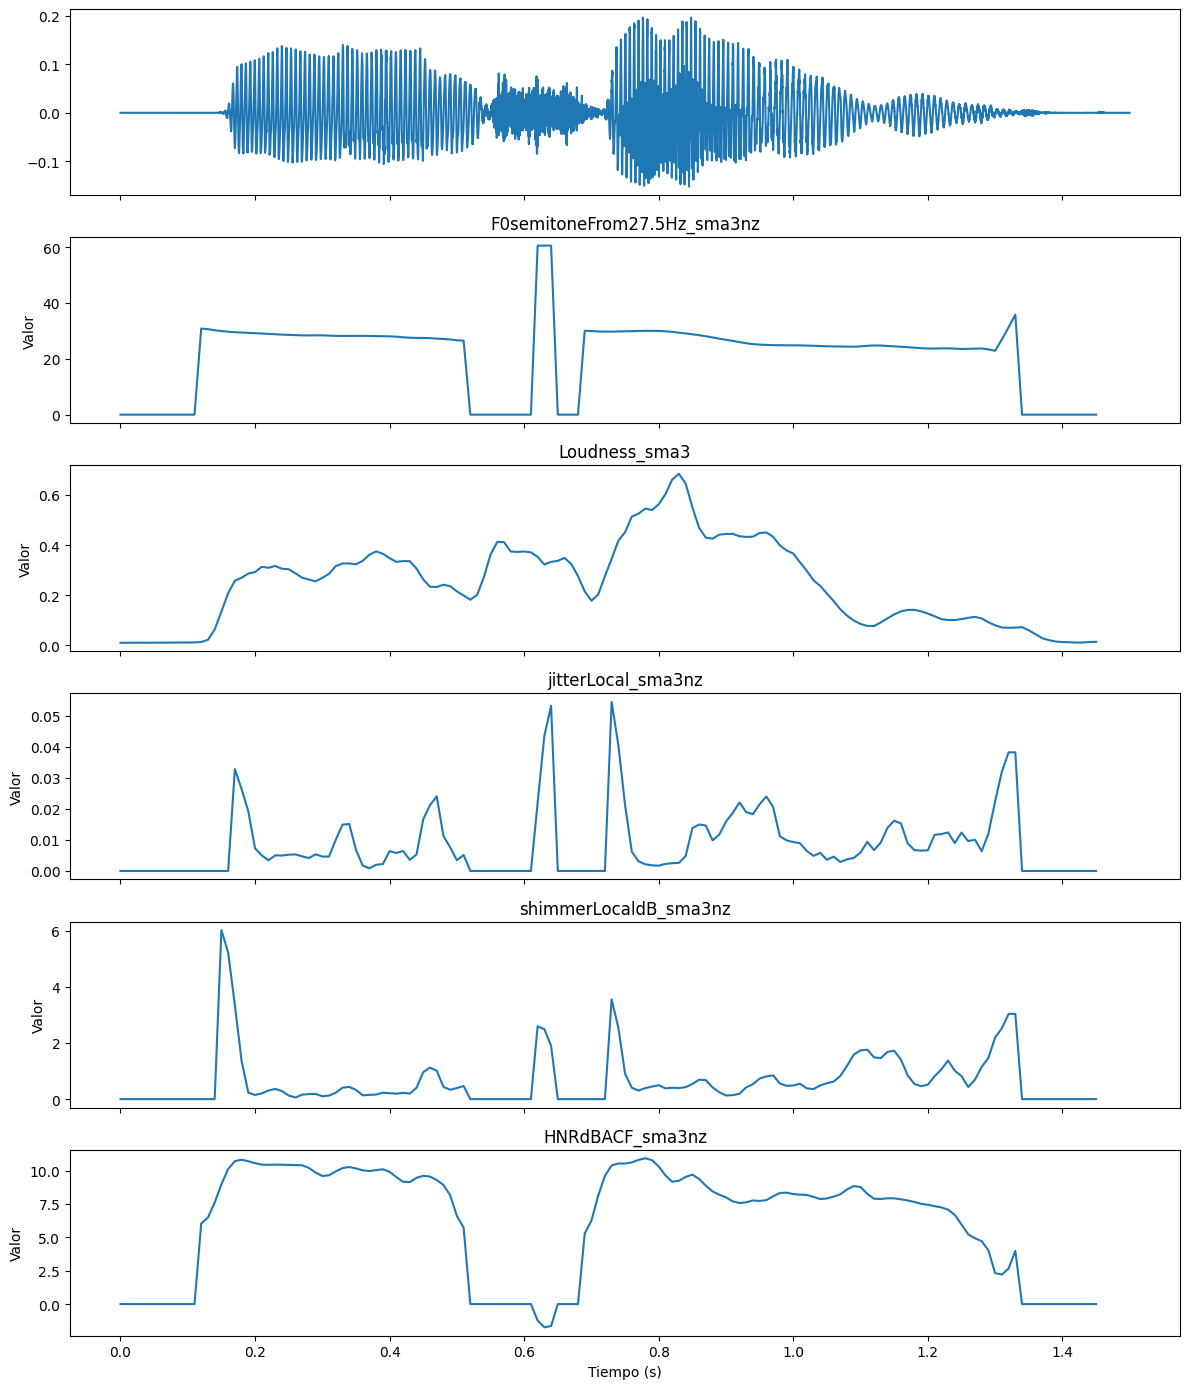

In [32]:
import opensmile

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors
)
df = smile.process_file("../../assets/murcielago.wav")
print("Atributos calculados:")
print(df.columns.tolist())

df.index = df.index.droplevel(0)
df.index = df.index.map(lambda x:x[0].total_seconds())

fig, axs = plt.subplots(6, 1, figsize=(12, 14), sharex=True)
axs[0].plot(tx, x, label='Forma de onda')
for i, feat in enumerate(['F0semitoneFrom27.5Hz_sma3nz','Loudness_sma3', 'jitterLocal_sma3nz','shimmerLocaldB_sma3nz', 'HNRdBACF_sma3nz']):
    axs[i+1].plot(df.index, df[feat], label=feat)
    axs[i+1].set_title(feat)
    axs[i+1].set_ylabel('Valor')
axs[i+1].set_xlabel('Tiempo (s)');
plt.tight_layout()
plt.show()

## Espectrograma

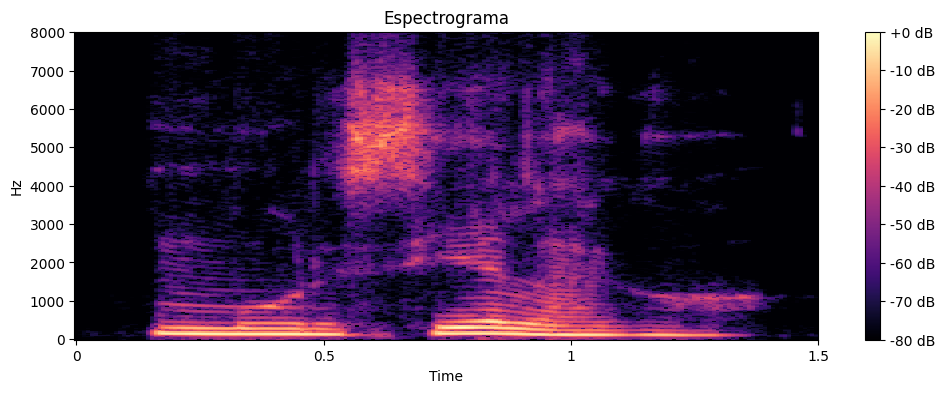

In [33]:
n_fft = 512
hop_length = 512 // 4
S  = librosa.amplitude_to_db(np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='linear', hop_length=hop_length);
plt.colorbar(format='%+2.0f dB');
plt.title('Espectrograma');
plt.show()

## Mel espectrograma

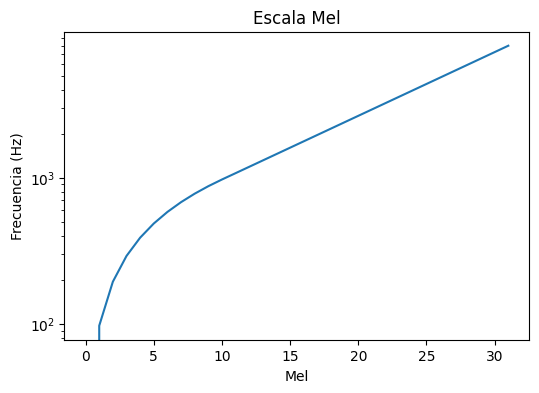

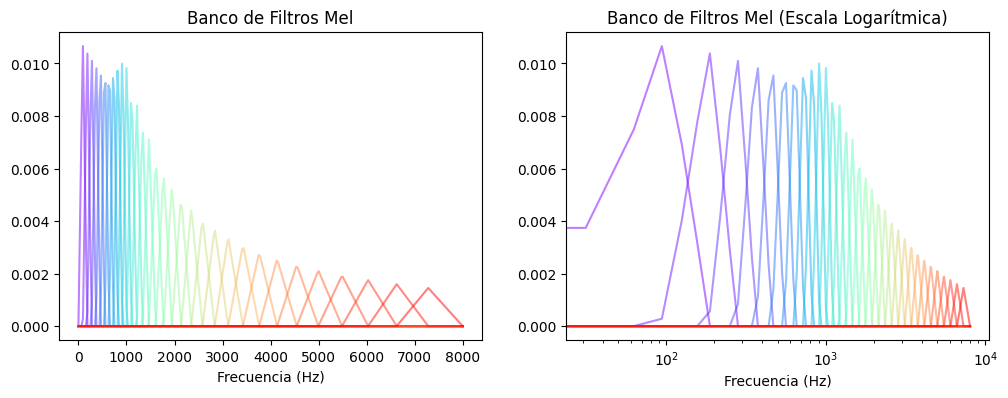

In [34]:
# mel filterbank
n_fft = 512
mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=32)
f_center = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

# mel_frequencies
mel_frequencies = librosa.mel_frequencies(n_mels=32, fmin=0, fmax=sr/2)
plt.figure(figsize=(6, 4))
plt.semilogy(mel_frequencies)
plt.title('Escala Mel')
plt.xlabel('Mel')
plt.ylabel('Frecuencia (Hz)')

# color cycle plasma
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.rainbow(np.linspace(0, 1, 32)))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(f_center, mel_basis.T, alpha=0.5, label='mel filterbank')
axs[0].set_title('Banco de Filtros Mel')
axs[0].set_xlabel('Frecuencia (Hz)')
axs[1].semilogx(f_center, mel_basis.T, alpha=0.5, label='mel filterbank')
axs[1].set_title('Banco de Filtros Mel (Escala Logarítmica)')
axs[1].set_xlabel('Frecuencia (Hz)')
plt.show()

# reset
plt.rcParams['axes.prop_cycle'] = plt.rcParamsDefault['axes.prop_cycle']
plt.show()

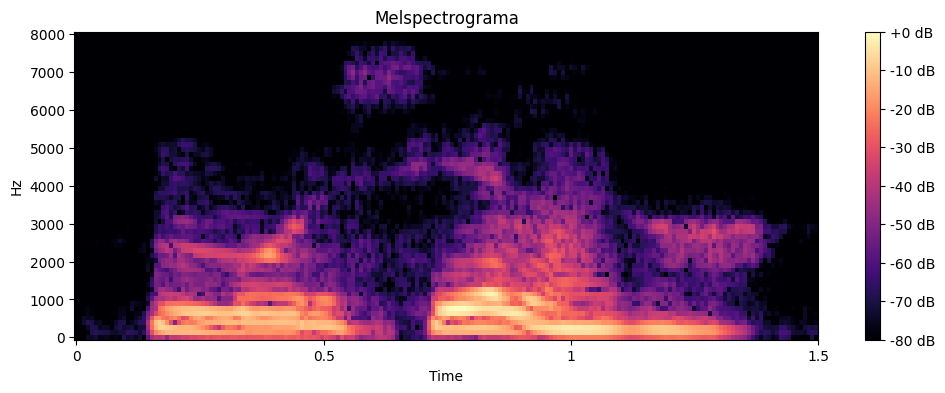

In [35]:
n_fft = 512
hop_length = 512 // 4
S = librosa.stft(x, n_fft=n_fft, hop_length=hop_length)
M = librosa.feature.melspectrogram(S=S, sr=sr, n_fft=n_fft, n_mels=64) 
M_db = librosa.amplitude_to_db(np.abs(M), ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(M_db, sr=sr, x_axis='time', y_axis='linear', hop_length=hop_length);
plt.colorbar(format='%+2.0f dB')
plt.title('Melspectrograma');
plt.show()

## Coeficientes Cepstrales en Frecuencias Mel (MFCC)

### Cepstrum
    
El cepstrum es una transformación que se utiliza para separar la información espectral de la información temporal en una señal. Se define como la transformada de Fourier del logaritmo de la magnitud del espectro de la señal. La ecuación del cepstrum es:

$$
\displaystyle C_{p}=\left|{\mathcal {F}}^{-1}\left\{\log \left(\left|{\mathcal {F}}\{x(t)\}\right|^{2}\right)\right\}\right|^{2}
$$

donde $\mathcal {F}$ es la transformada de Fourier, $x(t)$ es la señal de audio y $C_{p}$ es el cepstrum. La parte crucial en el cómputo es el logaritmo, si quitamos el logaritmo, el cepstrum se convierte en la autocorrelación. 

Veamos el cepstrum para las ventanas de la señal de voz. 

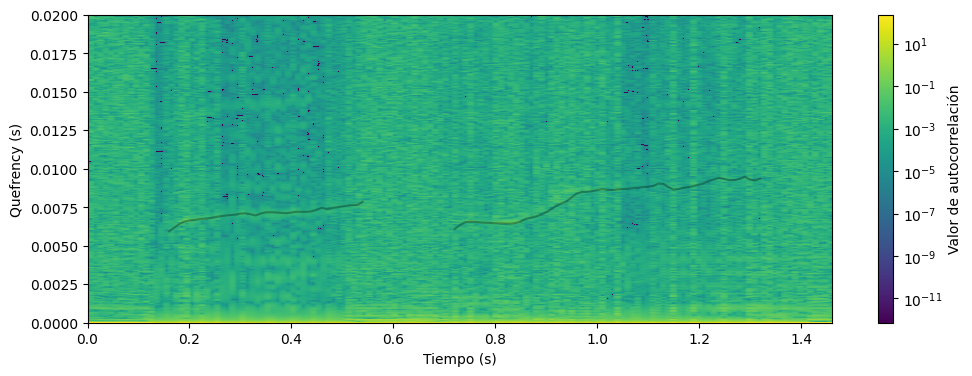

In [ ]:
# armamos ventanas
win_length = int(0.04*sr) # 40ms
hop_length = int(0.01*sr) # 10ms
X = frame(x, frame_length=win_length, hop_length=hop_length)
tf = frames_to_time(np.arange(X.shape[1]), sr=sr, hop_length=hop_length)

# cepstrum para cada venta
cepstrum = np.abs(np.fft.irfft(np.log(np.abs(np.fft.rfft(X,axis=0))**2+1e-10), axis=0))**2
cepstrum = cepstrum[:cepstrum.shape[0]//2,:]

plt.figure(figsize=(12, 4))
# LogNorm color map
from matplotlib.colors import LogNorm
plt.imshow(cepstrum, extent=(0, tf[-1], 0, cepstrum.shape[0]/sr), aspect='auto', origin='lower', norm=LogNorm());
plt.colorbar(label='Valor de autocorrelación')
plt.ylim(0, 0.02)

pitch = snd.to_pitch()
xp = pitch.xs()
yp = pitch.selected_array['frequency']
yp[yp==0] = np.nan
plt.plot(xp, 1/yp, label='periodo', color='black', alpha=0.3);
plt.xlabel('Tiempo (s)')
plt.ylabel('Quefrency (s)')
plt.show()


### MFCC

Los coeficientes cepstrales en frecuencias Mel (MFCC) son similares al cepstrum, pero además del logaritmo a la amplitud, se aplica una escala Mel a la frecuencia.
La forma habitual de calcular los MFCC es la siguiente:

1. Calcular el espectro de la señal de audio.
2. Aplicar una escala Mel a la frecuencia.
3. Aplicar el logaritmo a la magnitud del espectro.
4. Aplicar la transformada discreta de coseno (DCT) al resultado.
5. Tomar los primeros coeficientes como los MFCC.

La otra diferencia es que se usa la DCT en vez de la FFT. Esta transformada sirve solo para funciones reales y no genera una fase como resultado. Esta hecha por una base ortogonal de cosenos.


Computemos los MFCC paso a paso y comparemos con el resultado de librosa.

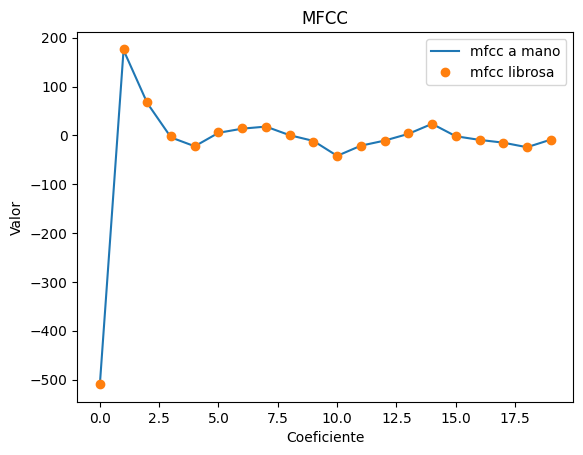

In [37]:
from scipy.signal.windows import hann
from scipy.fftpack import dct

# aplicamos la ventana de hanning
y = vocal*hann(len(vocal))

# calculamos el espectro
F = np.abs(np.fft.rfft(y))*4 # de donde sale el 4?

# calculamos los filtros mel
mel = librosa.filters.mel(sr=sr, n_fft=len(vocal), n_mels=128)

# aplicamos los filtros mel
M = np.dot(mel, F)

# pasamos a dB
M_db = 20*np.log10(M+1e-10)

# dct from scipy
mfcc = dct(M_db, type=2, axis=0, norm='ortho')

# tomamos los primeros 20 coeficientes
mfcc = mfcc[:20]

mfcc_librosa = librosa.feature.mfcc(y = vocal, sr=sr, n_mfcc=20, n_fft=len(vocal), n_mels=128, dct_type=2, norm='ortho', center=False)

plt.plot(mfcc,  label='mfcc a mano');
plt.plot(mfcc_librosa, 'o', label='mfcc librosa');
plt.title('MFCC')
plt.xlabel('Coeficiente')
plt.ylabel('Valor')
plt.legend()
plt.show()


Ahora veamos un MFCC grama, es decir calcuamos MFCC para cada ventana de la señal y graficamos el resultado.

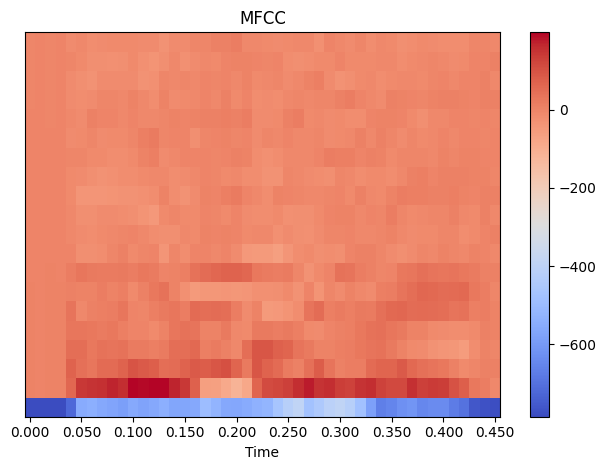

In [38]:
win_length = int(0.04*sr) # 40ms
hop_length = int(0.01*sr) # 10ms
mfcc = librosa.feature.mfcc(y = x, sr=sr, n_mfcc=20, n_fft=win_length, n_mels=128, dct_type=2, norm='ortho', center=False)

librosa.display.specshow(mfcc, sr=sr, x_axis='time', hop_length=hop_length)
plt.colorbar()
plt.title('MFCC')
plt.tight_layout()
plt.show()

Una de los principales usos de los MFCC es como entrada a algoritmos de aprendizaje automático. Su principal ventaja es que cada coeficiente está descorrelacionado con los demás, lo que significa que cada coeficiente representa una característica diferente de la señal. El primer coeficiente representa la energía de la señal, el segundo coeficiente representa una característica de pasabajos o pasaaltos, y los siguientes coeficientes representan envolventes espectrales con más detalles.

Si consideramos estos coeficientes como una entrada a un algoritmo de aprendizaje automático, nos puede interesar normalizar cada coeficiente restando su media y dividiendo por la desviación estandar de cada coeficiente. Esto se hace para que cada coeficiente tenga una escala similar.

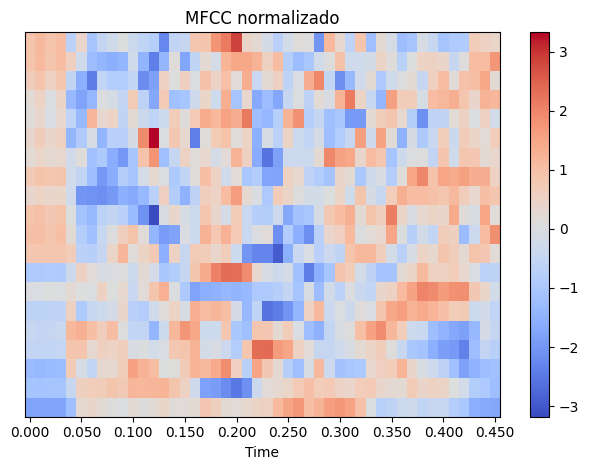

In [39]:
mfcc = mfcc-np.mean(mfcc, axis=1, keepdims=True)
mfcc = mfcc/np.std(mfcc, axis=1, keepdims=True)

librosa.display.specshow(mfcc, sr=sr, x_axis='time', hop_length=hop_length);
plt.colorbar()
plt.title('MFCC normalizado')
plt.tight_layout()
plt.show()

Como paso final, se suele combinar las MFCC con sus primeras y segundas derivadas. Esto se hace para capturar la dinámica de la señal en el tiempo. La combinación de los coeficientes y sus derivadas se llama _delta_ y _delta-delta_ respectivamente.


(60, 46)


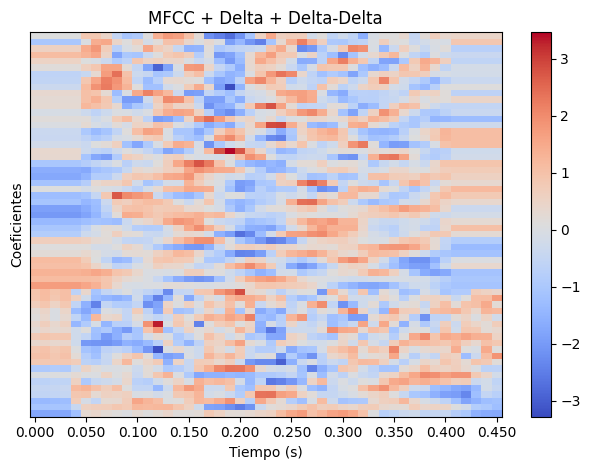

In [40]:
mfcc = librosa.feature.mfcc(y = x, sr=sr, n_mfcc=20, n_fft=win_length, n_mels=128, dct_type=2, norm='ortho', center=False)
mfcc_delta = librosa.feature.delta(mfcc, order=1)
mfcc_delta_delta = librosa.feature.delta(mfcc, order=2)
mfcc_combined = np.concatenate((mfcc, mfcc_delta, mfcc_delta_delta), axis=0)
mfcc_combined_norm = (mfcc_combined - np.mean(mfcc_combined, axis=1, keepdims=True)) / np.std(mfcc_combined, axis=1, keepdims=True)
print(mfcc_combined_norm.shape)
librosa.display.specshow(mfcc_combined_norm, x_axis='time', sr=sr, hop_length=hop_length);
plt.xlabel('Tiempo (s)')
plt.ylabel('Coeficientes')
plt.title('MFCC + Delta + Delta-Delta')
plt.colorbar()
plt.tight_layout()
plt.show()